# GP model evaluation — accuracy, calibration, and variance

Analyses the learned dynamics model of one training run, using the **last trial's GPs** (the model
the final policy was optimised against).

The question this notebook exists to answer is not "is the GP accurate?" — a one-step R^2 of 0.99
has coexisted with total multi-step collapse in this project. It is:

> **Is the GP's own uncertainty honest, and does it stay honest as the rollout runs forward?**

That matters because MC-PILCO never uses one-step predictions. It rolls 100 particles ~45 steps
forward and optimises the policy against the *mean* of that cloud. If the predictive variance is too
small the optimiser trusts a fiction; if it is enormous the mean is a meaningless summary of a
heavy-tailed distribution. Sections G.5-G.7 measure exactly that.

Layout:

| | what it answers |
|---|---|
| G.3 | what the GP actually learned — which inputs matter, how much it books as noise |
| G.4 | one-step accuracy per channel, in-sample vs held-out |
| G.5 | **calibration**: are the error bars the right size, one step out? |
| G.6 | multi-step rollout vs truth, with the model's own uncertainty band |
| G.7 | **does predicted variance keep pace with real error as the horizon grows?** |
| G.8 | k-step error growth |
| G.9 | off-distribution: does the GP still rank feed levels correctly? |

## G.0 Setup

In [1]:
%matplotlib inline
import os, sys, pickle, contextlib, io, glob, re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats

import os as _os, sys as _sys
_ROOT = _os.path.dirname(_os.path.abspath(""))
_sys.path.insert(0, _ROOT)
_sys.path.insert(0, _os.path.dirname(_ROOT))

from mcpilco.config_single_phase import get_config
from mcpilco.pensim_wrapper import (PenSimWrapper, PenSimMCPILCO, STATE_NAMES, STATE_DIM,
                                    STATE_RANGES, ACTION_DIM, T_SAMPLING, CONTROL_H,
                                    decode_state_value)
from experiments.eval_utils import yield_kg

ACTION_IDX = STATE_DIM                      # gp input = [state..., action]
INPUT_NAMES = STATE_NAMES + ["action"]
print("state:", STATE_NAMES, "| gp inputs:", INPUT_NAMES)

state: ['Wt', 'X', 'P', 'Viscosity', 'time'] | gp inputs: ['Wt', 'X', 'P', 'Viscosity', 'time', 'action']


## G.1 Config

`GP_TRIAL = None` selects the **last** trial with a saved GP — the model the final policy was
trained against, which is the one whose behaviour explains the deployed policy.

In [2]:
RUN_DIR = os.path.join(_ROOT, "results/single_phase/seed3_31")   # <-- the run to analyse
GP_TRIAL = None            # None = last saved trial
N_PARTICLES = 100          # matches the training-time particle count
SWEEP_ACTIONS = [-1.0, -0.5, 0.0, 0.5, 1.0]   # G.9 constant-action probe
PROBE_SEED = 720000        # held-out realisation for G.9

RUN_DIR = str(Path(RUN_DIR))
log = pickle.load(open(Path(RUN_DIR) / "log.pkl", "rb"))
meta = {}
note = Path(RUN_DIR) / "note.txt"
if note.exists():
    for line in note.read_text().splitlines():
        m = re.match(r"^(seed|num_trials|risk_weight|visc_penalty|harvest_reward) = (.+)$", line)
        if m:
            meta[m.group(1)] = m.group(2).strip()
SEED = int(meta.get("seed", 0))
NUM_TRIALS = int(meta.get("num_trials", len(log.get("parameters_trial_list", [])) or 1))

_gp_trials = sorted(int(k.split("_")[-1]) for k in log if k.startswith("parameters_gp_"))
assert _gp_trials, "log.pkl has no parameters_gp_<i> -- no trained GP to analyse"
GP_IDX = _gp_trials[-1] if GP_TRIAL is None else GP_TRIAL
assert GP_IDX in _gp_trials, f"trial {GP_IDX} not among saved GP trials {_gp_trials}"

# A model saved under a different STATE_DIM cannot be loaded into the current one.
_gp_dim = int(np.asarray(log[f"gp_inputs_{GP_IDX}"]).shape[1])
assert _gp_dim == STATE_DIM + ACTION_DIM, (
    f"run was trained with gp_input_dim={_gp_dim}, but the current state gives "
    f"{STATE_DIM + ACTION_DIM} ({INPUT_NAMES}). Re-train this run, or check out the code "
    f"version it was produced with.")

print(f"run {os.path.basename(RUN_DIR)} | seed {SEED} | saved GP trials {_gp_trials} -> using {GP_IDX}")
print("run params:", meta)

run seed3_31 | seed 3 | saved GP trials [4, 5, 6, 7, 8] -> using 8
run params: {'seed': '3', 'num_trials': '5', 'risk_weight': '0.0', 'visc_penalty': '0.5', 'harvest_reward': 'True'}


## G.2 Reconstruct the model

Rebuilds the agent and loads the saved GP state without retraining.

`norm_list` deliberately mirrors `flg_norm=False` from the training config. The GPs were fitted on
raw deltas, so rescaling here would distort the predictive variance by `norm^2` and silently corrupt
every calibration number below — which is the whole point of this notebook.

In [3]:
def reconstruct(seed, num_trials, log, idx):
    '''Build a PenSimMCPILCO and load the trial-`idx` GP model from `log` (no training).'''
    with contextlib.redirect_stdout(io.StringIO()):
        cfg = get_config(seed=seed, num_trials=num_trials)
        cfg["mc_pilco_init"]["log_path"] = None
        agent = PenSimMCPILCO(pensim_wrapper=PenSimWrapper(**cfg["wrapper_par"]),
                              **cfg["mc_pilco_init"])
    agent.state_samples_history = log["state_samples_history"]
    agent.input_samples_history = log["input_samples_history"]
    agent.noiseless_states_history = log.get("noiseless_states_history",
                                             log["state_samples_history"])
    ml = agent.model_learning
    ml.gp_inputs = log[f"gp_inputs_{idx}"]
    ml.gp_output_list = log[f"gp_output_list_{idx}"]
    ml.num_samples = ml.gp_inputs.shape[0]
    ml.dim_state = len(STATE_NAMES)
    ml.init_gp_models()
    params = log[f"parameters_gp_{idx}"]
    for k in range(ml.num_gp):
        ml.gp_list[k].load_state_dict(params[k])
        ml.norm_list[k] = (torch.max(torch.abs(ml.gp_output_list[k]))
                           if getattr(ml, "flg_norm", False)
                           else torch.tensor(1.0, dtype=agent.dtype))
    with torch.no_grad():
        for k in range(ml.num_gp):
            ml.pretrain_gp(k)
    ml.set_eval_mode()
    return agent


def _dn(x, lo, hi):
    return lo + (np.asarray(x) + 1.0) * (hi - lo) / 2.0

def _dn_delta(d, lo, hi):
    return np.asarray(d) * (hi - lo) / 2.0

def _phys(x, name):
    '''Normalised -> physical, inverting the log encode for logged channels.'''
    return decode_state_value(name, _dn(x, *STATE_RANGES[name]))

def _time_grid(N):
    return np.arange(N) * T_SAMPLING


agent = reconstruct(SEED, NUM_TRIALS, log, GP_IDX)
ml = agent.model_learning

# The GP was trained on batches 0..GP_IDX; the NEXT episode is genuinely unseen by this model.
IN_IDX = GP_IDX
HO_IDX = GP_IDX + 1
HAS_HO = HO_IDX < len(agent.state_samples_history)
print(f"training data: {ml.num_samples} points | in-sample batch {IN_IDX} | "
      f"held-out batch {HO_IDX if HAS_HO else 'NONE'}")


Selection of the inducing inputs...


/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/MC-PILCO/gpr_lib/GP_prior/GP_prior.py:106: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:1776.)
  U = torch.cholesky(K_X, upper=True)


Shape inducing inputs selected: torch.Size([218, 6])
MSE gp 0:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([370, 6])
MSE gp 1:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([377, 6])
MSE gp 2:  tensor(0.0003, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([466, 6])
MSE gp 3:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([305, 6])
MSE gp 4:  tensor(2.8771e-11, dtype=torch.float64)
training data: 540 points | in-sample batch 8 | held-out batch 9


## G.3 What the GP learned

Two hyperparameters per channel carry most of the story.

**Lengthscales** — an RBF weights each input by `1/lengthscale`, so a *short* lengthscale means the
output changes rapidly with that input, i.e. the GP considers it important. A lengthscale far larger
than the input's range means the channel is effectively **ignoring** that input. Since inputs are
normalised to `[-1, 1]`, anything above ~10 is being ignored.

**Noise (`sigma_n`)** — how much of the observed variation the GP gave up on explaining. Inflated
noise on one channel means the deterministic structure there is not being captured (this is what
`Wt` looked like before the mass-balance prior mean took it from R^2 0.13 to ~0.95).

,channel,signal_sd,noise_sd,signal/noise,ls_Wt,ls_X,ls_P,ls_Viscosity,ls_time,ls_action
0,Wt,0.3105,0.0152,20.4498,6.7028,8.7976,7.3103,7.3142,5.8334,7.2132
1,X,0.3036,0.0138,21.9249,4.6774,0.4633,2.3611,5.2039,2.0214,9.3207
2,P,0.2280,0.0173,13.1664,7.4297,0.1163,1.6784,5.3368,4.5005,8.7397
3,Viscosity,0.3715,0.0337,11.0080,0.4855,1.4363,1.4552,0.6485,3.6711,NaN
4,time,0.2579,0.0011,244.0866,10.8488,12.3681,12.8740,10.3284,10.9783,10.6146


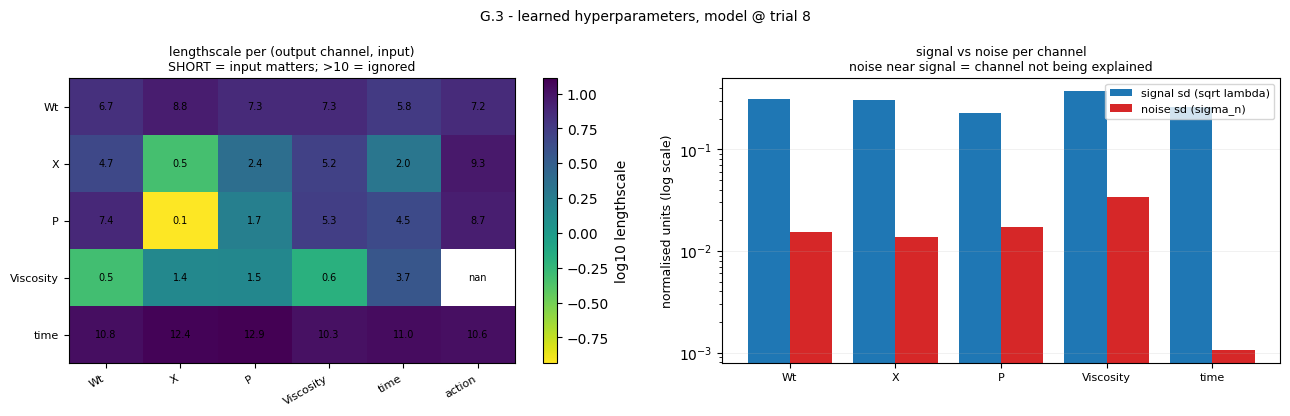

effectively IGNORED inputs (lengthscale > 10): [('time', 'Wt'), ('time', 'X'), ('time', 'P'), ('time', 'Viscosity'), ('time', 'time'), ('time', 'action')]


In [4]:
rows = []
for k, name in enumerate(STATE_NAMES):
    gp = ml.gp_list[k]
    sd = gp.state_dict()
    ls = torch.exp(sd["log_lengthscales_par"]).detach().cpu().numpy().ravel()
    lam = float(torch.exp(sd["log_lambda_par"]).detach().cpu().numpy().ravel()[0])
    # GP_prior: noise VARIANCE = exp(sigma_n_log)^2 + sigma_n_num^2
    sn = float(np.sqrt(np.exp(float(sd["sigma_n_log"].ravel()[0])) ** 2
                       + float(getattr(gp, "sigma_n_num", 0.0)) ** 2))
    r = {"channel": name, "signal_sd": np.sqrt(lam), "noise_sd": sn,
         "signal/noise": np.sqrt(lam) / sn if sn else np.inf}
    r.update({f"ls_{n}": v for n, v in zip(INPUT_NAMES, ls)})
    rows.append(r)
hyp = pd.DataFrame(rows)
display(hyp.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
L = np.array([[hyp.loc[i, f"ls_{n}"] for n in INPUT_NAMES] for i in range(len(hyp))])
im = ax[0].imshow(np.log10(L), cmap="viridis_r", aspect="auto")
ax[0].set_xticks(range(len(INPUT_NAMES))); ax[0].set_xticklabels(INPUT_NAMES, fontsize=8, rotation=30, ha="right")
ax[0].set_yticks(range(len(STATE_NAMES))); ax[0].set_yticklabels(STATE_NAMES, fontsize=8)
for i in range(L.shape[0]):
    for j in range(L.shape[1]):
        ax[0].text(j, i, f"{L[i, j]:.1f}", ha="center", va="center", fontsize=7,
                   color="white" if np.log10(L[i, j]) < np.log10(L).mean() else "black")
ax[0].set_title("lengthscale per (output channel, input)\nSHORT = input matters; >10 = ignored", fontsize=9)
plt.colorbar(im, ax=ax[0], label="log10 lengthscale")

a = ax[1]
xs = np.arange(len(STATE_NAMES))
a.bar(xs - .2, hyp["signal_sd"], width=.4, color="C0", label="signal sd (sqrt lambda)")
a.bar(xs + .2, hyp["noise_sd"], width=.4, color="C3", label="noise sd (sigma_n)")
a.set_yscale("log"); a.set_xticks(xs); a.set_xticklabels(STATE_NAMES, fontsize=8)
a.set_ylabel("normalised units (log scale)", fontsize=9)
a.set_title("signal vs noise per channel\nnoise near signal = channel not being explained", fontsize=9)
a.grid(alpha=.25, lw=.5, axis="y"); a.legend(fontsize=8)
fig.suptitle(f"G.3 - learned hyperparameters, model @ trial {GP_IDX}", fontsize=10)
fig.tight_layout(); plt.show()

_ignored = [(hyp.loc[i, "channel"], n) for i in range(len(hyp))
            for n in INPUT_NAMES if hyp.loc[i, f"ls_{n}"] > 10]
print("effectively IGNORED inputs (lengthscale > 10):",
      _ignored if _ignored else "none -- every channel uses every input")

## G.4 One-step accuracy, in-sample vs held-out

Teacher-forced: the true state is fed at every step, so this isolates the one-step map with no error
accumulation. Reported per channel in **physical units** so the numbers are interpretable, and as
R^2 so they are comparable across channels with different scales.

A large in-sample/held-out gap means overfitting. A small gap with good numbers here still tells you
nothing about multi-step behaviour — that is G.6 onward.

,channel,batch,rmse_norm,rmse_phys,r2_level
0,Wt,in-sample,0.0123,0.0059,0.9987
1,Wt,held-out,0.0149,0.0071,0.9986
2,X,in-sample,0.0168,0.0562,0.9904
3,X,held-out,0.0155,0.0519,0.9929
4,P,in-sample,0.0125,0.0525,0.9995
5,P,held-out,0.0175,0.0735,0.9989
6,Viscosity,in-sample,0.0140,0.8394,0.9988
7,Viscosity,held-out,0.0139,0.8341,0.9984
8,time,in-sample,0.0000,0.0000,1.0000
9,time,held-out,0.0000,0.0000,1.0000


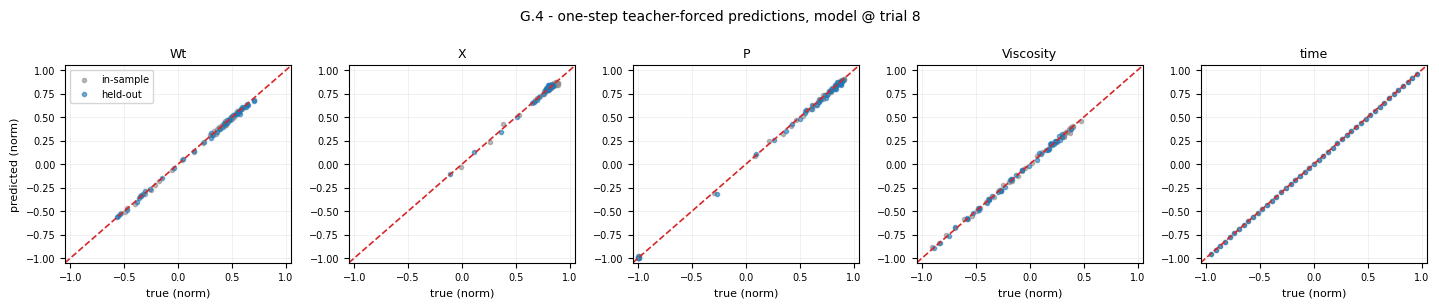

In [5]:
def _one_step(batch_idx):
    '''Teacher-forced one-step predictions for a batch -> (pred, true, pred_std) normalised.'''
    tr = torch.tensor(agent.state_samples_history[batch_idx], dtype=agent.dtype, device=agent.device)
    ip = torch.tensor(agent.input_samples_history[batch_idx], dtype=agent.dtype, device=agent.device)
    N = tr.shape[0]
    pred = np.zeros((N - 1, STATE_DIM)); std = np.zeros((N - 1, STATE_DIM))
    with torch.no_grad():
        for t in range(N - 1):
            nxt, _dm, dv = ml.get_next_state(current_state=tr[t:t + 1], current_input=ip[t:t + 1],
                                             particle_pred=False)
            pred[t] = nxt.ravel().cpu().numpy()
            std[t] = torch.sqrt(dv).ravel().cpu().numpy()
    return pred, tr[1:].cpu().numpy(), std


os_in = _one_step(IN_IDX)
os_ho = _one_step(HO_IDX) if HAS_HO else None

rows = []
for k, name in enumerate(STATE_NAMES):
    lo, hi = STATE_RANGES[name]
    for tag, d in ([("in-sample", os_in)] + ([("held-out", os_ho)] if HAS_HO else [])):
        p, t = d[0][:, k], d[1][:, k]
        # R^2 on the DELTA is the honest measure: predicting "no change" already tracks the level.
        ss_res = float(((p - t) ** 2).sum()); ss_tot = float(((t - t.mean()) ** 2).sum())
        rows.append({"channel": name, "batch": tag,
                     "rmse_norm": float(np.sqrt(((p - t) ** 2).mean())),
                     "rmse_phys": float(np.sqrt(((_dn_delta(p, lo, hi) - _dn_delta(t, lo, hi)) ** 2).mean())),
                     "r2_level": 1 - ss_res / (ss_tot or 1.0)})
acc = pd.DataFrame(rows)
display(acc.round(4))

fig, ax = plt.subplots(1, STATE_DIM, figsize=(2.9 * STATE_DIM, 3.1), squeeze=False)
for k, name in enumerate(STATE_NAMES):
    a = ax[0, k]
    for tag, d, col in ([("in-sample", os_in, "0.55")]
                        + ([("held-out", os_ho, "C0")] if HAS_HO else [])):
        a.scatter(d[1][:, k], d[0][:, k], s=9, alpha=.6, color=col, label=tag)
    lims = [-1.05, 1.05]
    a.plot(lims, lims, "C3--", lw=1.2)
    a.set_xlim(lims); a.set_ylim(lims)
    a.set_title(name, fontsize=9); a.set_xlabel("true (norm)", fontsize=8)
    a.grid(alpha=.25, lw=.5); a.tick_params(labelsize=7)
    if k == 0:
        a.set_ylabel("predicted (norm)", fontsize=8); a.legend(fontsize=7)
fig.suptitle(f"G.4 - one-step teacher-forced predictions, model @ trial {GP_IDX}", fontsize=10)
fig.tight_layout(); plt.show()

## G.5 Calibration — are the error bars the right size?

Standardise each one-step residual by the GP's *own* predicted std. A well-calibrated channel gives
`z ~ N(0, 1)`: mean 0, std 1, and ~95% of points within +/-1.96.

- **std(z) > 1** → the GP is **overconfident**; real errors are bigger than it claims. The optimiser
  will trust predictions it should not.
- **std(z) < 1** → **underconfident**; error bars wider than needed, so the mean is a vague summary
  and gradients are noisy.

This is the single most useful GP diagnostic here, because accuracy and calibration fail
independently — a model can be accurate and overconfident at the same time.

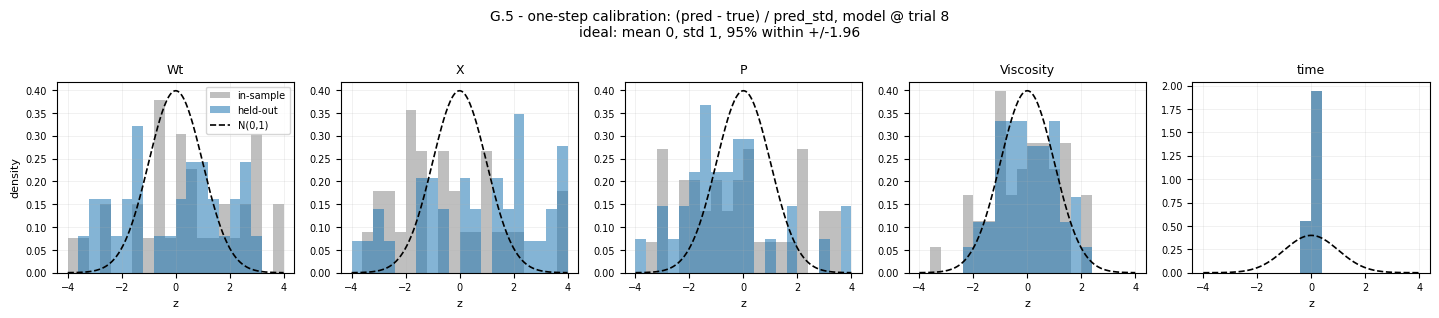

,channel,batch,mean_z,std_z,within_1.96,verdict
0,Wt,in-sample,-0.212,3.542,0.422,overconfident
1,Wt,held-out,-1.121,3.783,0.378,overconfident
2,X,in-sample,-1.314,4.735,0.422,overconfident
3,X,held-out,2.022,3.627,0.400,overconfident
4,P,in-sample,-0.506,2.827,0.467,overconfident
5,P,held-out,-1.753,3.288,0.556,overconfident
6,Viscosity,in-sample,-0.178,1.452,0.822,overconfident
7,Viscosity,held-out,0.043,1.043,0.956,ok
8,time,in-sample,-0.000,0.000,1.000,underconfident
9,time,held-out,-0.000,0.000,1.000,underconfident


In [6]:
def _z_resid(d):
    return (d[0] - d[1]) / np.where(d[2] > 0, d[2], np.nan)

z_in = _z_resid(os_in)
z_ho = _z_resid(os_ho) if HAS_HO else None

xg = np.linspace(-4, 4, 200); npdf = np.exp(-xg ** 2 / 2) / np.sqrt(2 * np.pi)
fig, ax = plt.subplots(1, STATE_DIM, figsize=(2.9 * STATE_DIM, 3.2), squeeze=False)
rows = []
for k, name in enumerate(STATE_NAMES):
    a = ax[0, k]
    for z, tag, col in ([(z_in, "in-sample", "0.55")] + ([(z_ho, "held-out", "C0")] if HAS_HO else [])):
        zc = z[:, k]; zc = zc[np.isfinite(zc)]
        if zc.size == 0:
            continue
        a.hist(zc, bins=20, range=(-4, 4), density=True, alpha=.55, color=col, label=tag)
        rows.append({"channel": name, "batch": tag, "mean_z": zc.mean(), "std_z": zc.std(),
                     "within_1.96": float(np.mean(np.abs(zc) < 1.96)),
                     "verdict": "overconfident" if zc.std() > 1.3
                                else ("underconfident" if zc.std() < 0.7 else "ok")})
    a.plot(xg, npdf, "k--", lw=1.2, label="N(0,1)")
    a.set_title(name, fontsize=9); a.set_xlabel("z", fontsize=8)
    a.grid(alpha=.25, lw=.5); a.tick_params(labelsize=7)
    if k == 0:
        a.set_ylabel("density", fontsize=8); a.legend(fontsize=7)
fig.suptitle(f"G.5 - one-step calibration: (pred - true) / pred_std, model @ trial {GP_IDX}\n"
             "ideal: mean 0, std 1, 95% within +/-1.96", fontsize=10)
fig.tight_layout(); plt.show()
display(pd.DataFrame(rows).round(3))

## G.6 Multi-step rollout with the model's own uncertainty

`N_PARTICLES` particles from the true initial state, driven by the batch's **recorded** actions, each
step sampling `delta ~ N(mean, var)` — exactly the machinery policy optimisation uses.

Read two things:

- **Does the truth stay inside the band?** Coverage well below 80% means overconfident; ~100% with a
  band spanning the whole physical range means the model is saying "I don't know".
- **Does the median track the truth?** The optimiser plans against the mean path, so a median that
  drifts away from reality is what the policy is actually being optimised for.

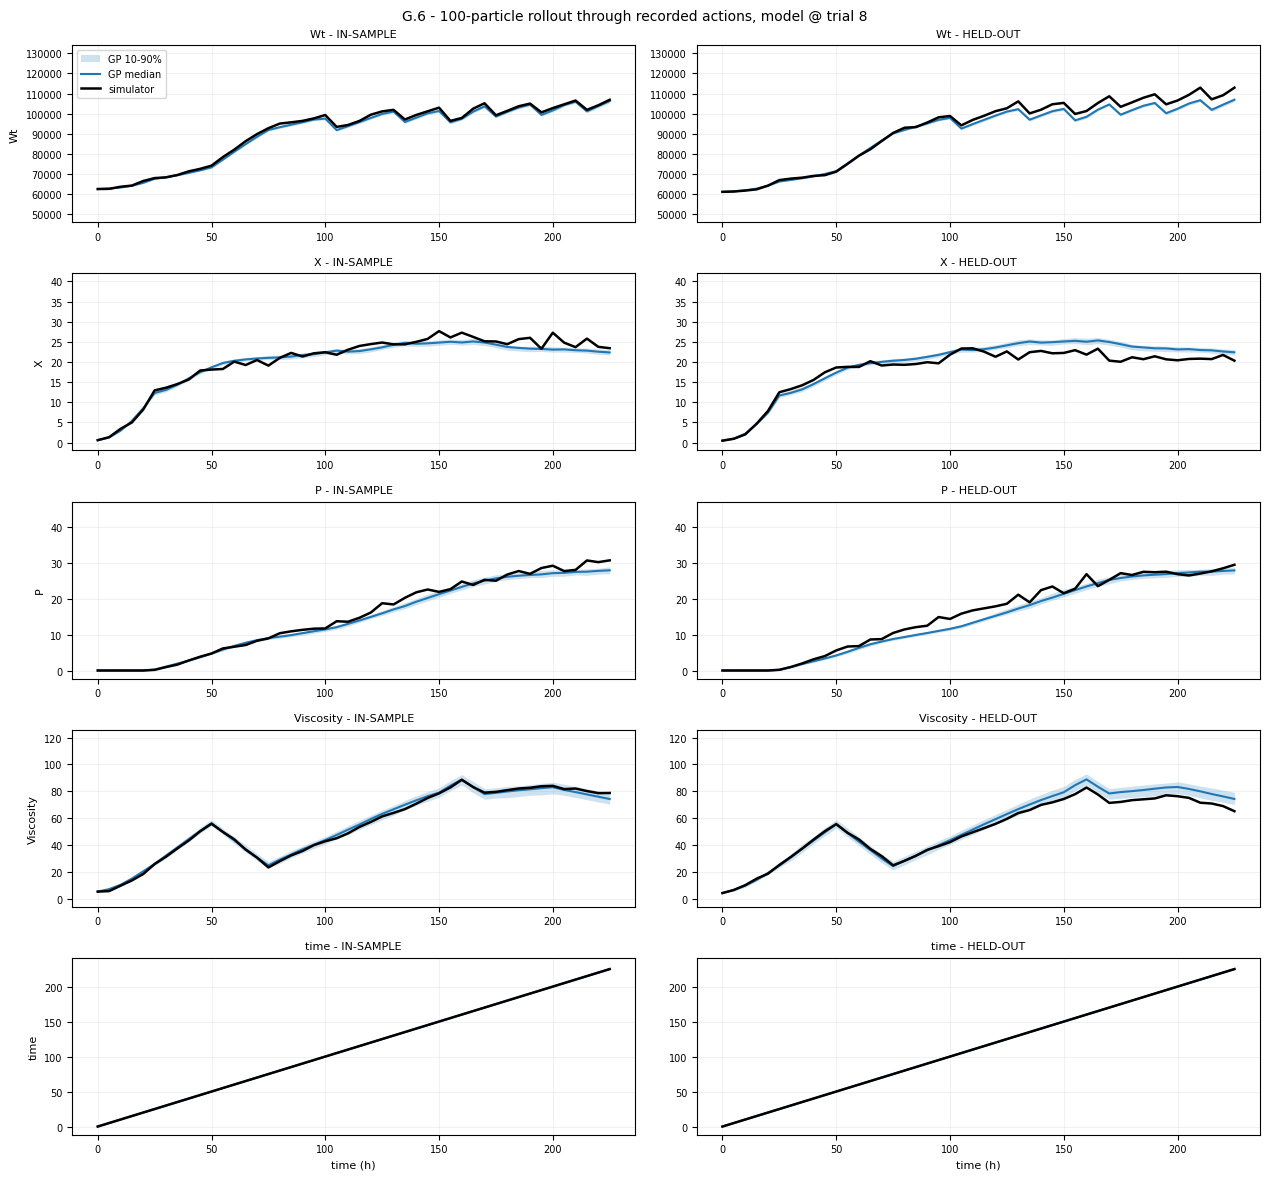

,channel,batch,coverage_10_90,band_width_end,median_err_end
0,Wt,IN-SAMPLE,0.348,1929.650,-631.019
1,Wt,HELD-OUT,0.283,1941.060,-5986.959
2,X,IN-SAMPLE,0.348,1.312,-1.051
3,X,HELD-OUT,0.130,1.352,2.073
4,P,IN-SAMPLE,0.457,1.923,-2.781
5,P,HELD-OUT,0.391,1.952,-1.566
6,Viscosity,IN-SAMPLE,0.935,8.312,-4.479
7,Viscosity,HELD-OUT,0.609,9.144,9.115
8,time,IN-SAMPLE,0.022,0.000,-0.000
9,time,HELD-OUT,0.022,0.000,-0.000


coverage ~0.8 is ideal. << 0.8 => overconfident. ~1.0 with a huge band => uninformative.


In [7]:
def _particle_rollout(batch_idx, N=None):
    N = N or N_PARTICLES
    S = np.asarray(agent.state_samples_history[batch_idx])
    U = np.asarray(agent.input_samples_history[batch_idx])
    T = S.shape[0]
    torch.manual_seed(0)
    x = torch.tensor(np.tile(S[0], (N, 1)), dtype=agent.dtype, device=agent.device)
    out = np.zeros((T, N, STATE_DIM)); out[0] = x.cpu().numpy()
    with torch.no_grad():
        for t in range(1, T):
            u = torch.tensor(np.tile(U[t - 1], (N, 1)), dtype=agent.dtype, device=agent.device)
            x, _, _ = ml.get_next_state(current_state=x, current_input=u, particle_pred=True)
            out[t] = x.cpu().numpy()
    return out, S


cols = [(IN_IDX, "IN-SAMPLE")] + ([(HO_IDX, "HELD-OUT")] if HAS_HO else [])
roll = {i: _particle_rollout(i) for i, _ in cols}

fig, ax = plt.subplots(STATE_DIM, len(cols), figsize=(6.4 * len(cols), 2.4 * STATE_DIM), squeeze=False)
cov_rows = []
for r, name in enumerate(STATE_NAMES):
    lo, hi = STATE_RANGES[name]
    lo_p, hi_p = decode_state_value(name, lo), decode_state_value(name, hi)
    for c, (bidx, tag) in enumerate(cols):
        tr, S = roll[bidx]
        v = _phys(tr[:, :, r], name); truth = _phys(S[:, r], name)
        p10, p50, p90 = (np.percentile(v, 10, axis=1), np.median(v, axis=1),
                         np.percentile(v, 90, axis=1))
        t = _time_grid(tr.shape[0])
        a = ax[r, c]
        a.fill_between(t, p10, p90, color="C0", alpha=.22, lw=0, label="GP 10-90%")
        a.plot(t, p50, color="C0", lw=1.5, label="GP median")
        a.plot(t, truth, "k-", lw=1.8, label="simulator")
        a.set_ylim(lo_p - .05 * (hi_p - lo_p), hi_p + .05 * (hi_p - lo_p))
        a.set_title(f"{name} - {tag}", fontsize=8)
        a.grid(alpha=.25, lw=.5); a.tick_params(labelsize=7)
        if c == 0:
            a.set_ylabel(name, fontsize=8)
        if r == STATE_DIM - 1:
            a.set_xlabel("time (h)", fontsize=8)
        if r == 0 and c == 0:
            a.legend(fontsize=7, loc="upper left")
        cov_rows.append({"channel": name, "batch": tag,
                         "coverage_10_90": float(np.mean((truth >= p10) & (truth <= p90))),
                         "band_width_end": float(p90[-1] - p10[-1]),
                         "median_err_end": float(p50[-1] - truth[-1])})
fig.suptitle(f"G.6 - {N_PARTICLES}-particle rollout through recorded actions, model @ trial {GP_IDX}",
             fontsize=10)
fig.tight_layout(); plt.show()
display(pd.DataFrame(cov_rows).round(3))
print("coverage ~0.8 is ideal. << 0.8 => overconfident. ~1.0 with a huge band => uninformative.")

## G.7 Does the variance keep pace with the error?

The core question. At every horizon `k`, compare:

- **actual error** — RMSE of the mean prediction against the simulator, sliding-origin
- **claimed uncertainty** — the GP's own predicted std at that horizon

Their *ratio* is the calibration curve. A model can be perfectly calibrated one step out (G.5) and
badly overconfident by step 20, and that is precisely the regime the policy optimiser works in.

**ratio > 1 → overconfident at that horizon.** The optimiser is planning against predictions whose
true error exceeds the error bars it was given.

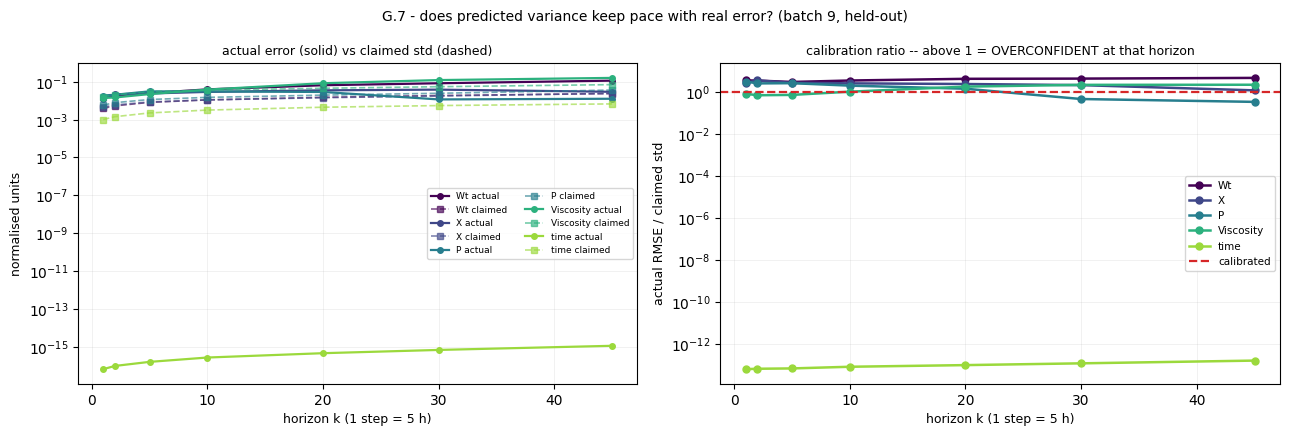

,Wt,X,P,Viscosity,time
k=1,3.64,2.81,3.22,0.84,0.0
k=2,3.57,3.65,2.62,0.72,0.0
k=5,3.07,2.80,2.69,0.74,0.0
k=10,3.60,2.64,2.05,1.06,0.0
k=20,4.34,2.46,1.47,1.84,0.0
k=30,4.44,2.18,0.47,2.24,0.0
k=45,4.80,1.22,0.35,2.27,0.0



At the longest horizon (k=45), overconfident channels: [('Wt', 4.802248204158799), ('Viscosity', 2.266664820559641)]


In [8]:
HORIZONS = np.array([h for h in (1, 2, 5, 10, 20, 30, 45) if h <= len(agent.state_samples_history[IN_IDX]) - 1])

def _err_vs_std(batch_idx, horizons, origins=40):
    '''Sliding-origin: actual RMSE and mean predicted std at each horizon (normalised units).'''
    true = torch.tensor(agent.state_samples_history[batch_idx], dtype=agent.dtype, device=agent.device)
    inp = torch.tensor(agent.input_samples_history[batch_idx], dtype=agent.dtype, device=agent.device)
    T = true.shape[0]; kmax = int(horizons.max())
    stride = max(1, int(np.ceil((T - 1) / origins)))
    sq = {int(k): [] for k in horizons}; sd = {int(k): [] for k in horizons}
    with torch.no_grad():
        for t0 in range(0, T - 1, stride):
            steps = min(kmax, T - 1 - t0)
            cur = true[t0:t0 + 1, :]
            var_acc = torch.zeros(1, STATE_DIM, dtype=agent.dtype, device=agent.device)
            for j in range(1, steps + 1):
                cur, _dm, dv = ml.get_next_state(current_state=cur,
                                                 current_input=inp[t0 + j - 1:t0 + j, :],
                                                 particle_pred=False)
                # Deterministic mean path: per-step variances accumulate along the horizon.
                var_acc = var_acc + dv
                if j in sq:
                    sq[j].append(((cur - true[t0 + j:t0 + j + 1, :]).ravel() ** 2).cpu().numpy())
                    sd[j].append(torch.sqrt(var_acc).ravel().cpu().numpy())
    rmse = np.full((len(horizons), STATE_DIM), np.nan)
    pstd = np.full((len(horizons), STATE_DIM), np.nan)
    for r, k in enumerate(horizons):
        if sq[int(k)]:
            rmse[r] = np.sqrt(np.mean(np.stack(sq[int(k)]), 0))
            pstd[r] = np.mean(np.stack(sd[int(k)]), 0)
    return rmse, pstd


bidx = HO_IDX if HAS_HO else IN_IDX
rmse_k, pstd_k = _err_vs_std(bidx, HORIZONS)
ratio = rmse_k / np.where(pstd_k > 0, pstd_k, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
_cmap = cm.viridis(np.linspace(0, .85, STATE_DIM))
for k, name in enumerate(STATE_NAMES):
    ax[0].plot(HORIZONS, rmse_k[:, k], "-o", color=_cmap[k], lw=1.6, ms=4, label=f"{name} actual")
    ax[0].plot(HORIZONS, pstd_k[:, k], "--s", color=_cmap[k], lw=1.2, ms=4, alpha=.65,
               label=f"{name} claimed")
ax[0].set_xlabel(f"horizon k (1 step = {T_SAMPLING:g} h)", fontsize=9)
ax[0].set_ylabel("normalised units", fontsize=9); ax[0].set_yscale("log")
ax[0].set_title("actual error (solid) vs claimed std (dashed)", fontsize=9)
ax[0].grid(alpha=.25, lw=.5, which="both"); ax[0].legend(fontsize=6.5, ncol=2)

for k, name in enumerate(STATE_NAMES):
    ax[1].plot(HORIZONS, ratio[:, k], "-o", color=_cmap[k], lw=1.8, ms=5, label=name)
ax[1].axhline(1.0, color="C3", ls="--", lw=1.6, label="calibrated")
ax[1].set_xlabel(f"horizon k (1 step = {T_SAMPLING:g} h)", fontsize=9)
ax[1].set_ylabel("actual RMSE / claimed std", fontsize=9); ax[1].set_yscale("log")
ax[1].set_title("calibration ratio -- above 1 = OVERCONFIDENT at that horizon", fontsize=9)
ax[1].grid(alpha=.25, lw=.5, which="both"); ax[1].legend(fontsize=7.5)

fig.suptitle(f"G.7 - does predicted variance keep pace with real error? "
             f"(batch {bidx}, {'held-out' if HAS_HO else 'in-sample'})", fontsize=10)
fig.tight_layout(); plt.show()

display(pd.DataFrame(ratio, index=[f"k={k}" for k in HORIZONS], columns=STATE_NAMES).round(2))
_bad = [(STATE_NAMES[k], float(ratio[-1, k])) for k in range(STATE_DIM) if ratio[-1, k] > 1.5]
print(f"\nAt the longest horizon (k={HORIZONS[-1]}), overconfident channels:",
      _bad if _bad else "none")

## G.8 k-step error growth in physical units

Same sliding-origin errors as G.7, converted to physical units so the magnitude is interpretable:
how many g/L of penicillin is the model wrong by, 20 steps out?

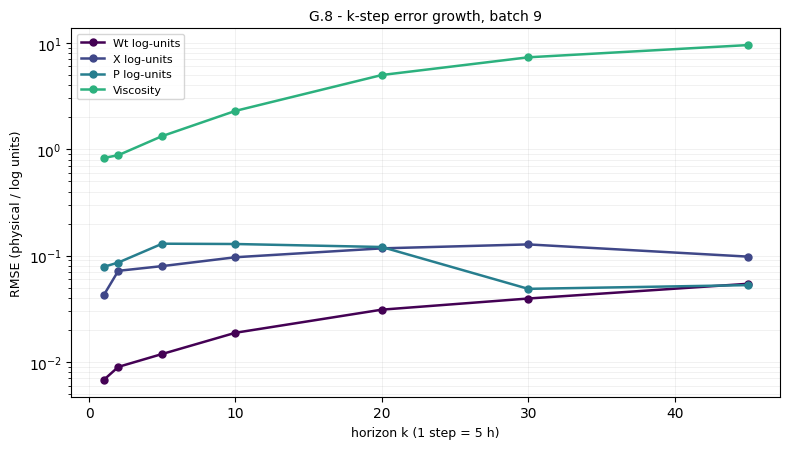

Wt, X and P are LOG-encoded, so their RMSE is in log units: 0.1 ~ a 10% multiplicative error.
These are the integrating channels -- errors here accumulate rather than self-correct.


In [9]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for k, name in enumerate(STATE_NAMES):
    if name == "time":
        continue
    lo, hi = STATE_RANGES[name]
    y = _dn_delta(rmse_k[:, k], lo, hi)
    unit = "log-units" if name in ("Wt", "X", "P") else ""
    ax.plot(HORIZONS, y, "-o", color=_cmap[k], lw=1.8, ms=5, label=f"{name} {unit}".strip())
ax.set_xlabel(f"horizon k (1 step = {T_SAMPLING:g} h)", fontsize=9)
ax.set_ylabel("RMSE (physical / log units)", fontsize=9)
ax.set_yscale("log"); ax.grid(alpha=.25, lw=.5, which="both"); ax.legend(fontsize=8)
ax.set_title(f"G.8 - k-step error growth, batch {bidx}", fontsize=10)
fig.tight_layout(); plt.show()

print("Wt, X and P are LOG-encoded, so their RMSE is in log units: 0.1 ~ a 10% multiplicative error.")
print("These are the integrating channels -- errors here accumulate rather than self-correct.")

## G.9 Off-distribution: does the GP still rank feed levels correctly?

Everything above evaluates the GP on trajectories it was trained near. The policy optimiser does not
stay there — it searches the whole action band, and a model that mis-ranks feed levels will send it
somewhere the reactor cannot go.

This probe drives constant actions across the band through both the **GP** and the **real
simulator**, on the same held-out seed, and compares final penicillin. What matters is not absolute
accuracy but **monotonic agreement**: if the GP thinks `a=+1` is best while the simulator says it
collapses the batch, every optimisation run will chase that.

,action,sim_final_P,sim_yield_kg,sim_max_visc,gp_median_P,gp_p10_P,gp_p90_P
0,-1.0,22.28,2372.24,67.27,17.54,1.01,25.51
1,-0.5,25.61,2941.37,75.71,24.22,18.29,26.18
2,0.0,28.37,3502.69,82.60,25.99,25.23,26.94
3,0.5,27.93,3546.59,95.36,26.87,26.00,27.71
4,1.0,3.37,564.54,181.75,27.91,26.62,29.21


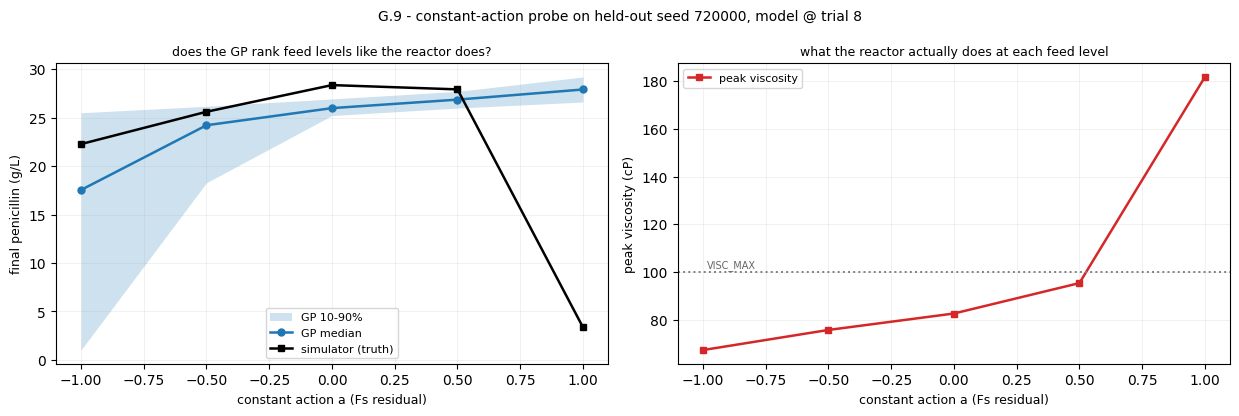

GP vs simulator ranking across the action band: Spearman rho=-0.10 (p=0.873)
rho near +1 => the GP orders feed levels the way the reactor does, which is what the
optimiser needs. Near 0 or negative => it will optimise toward the wrong action.

GP's preferred action: +1.0 | simulator's best: +0.0


In [10]:
wrapper = PenSimWrapper()
rows = []
for a_val in SWEEP_ACTIONS:
    # --- real simulator ---
    with contextlib.redirect_stdout(io.StringIO()):
        S, U, _ = wrapper.rollout(None, lambda s, i, _a=a_val: np.array([_a]),
                                  CONTROL_H, T_SAMPLING, 0, seed=PROBE_SEED)
    mon = wrapper.monitor[-1]
    # --- GP, same action, same start state ---
    torch.manual_seed(0)
    x = torch.tensor(np.tile(S[0], (N_PARTICLES, 1)), dtype=agent.dtype, device=agent.device)
    u = torch.full((N_PARTICLES, ACTION_DIM), float(a_val), dtype=agent.dtype, device=agent.device)
    with torch.no_grad():
        for _ in range(1, S.shape[0]):
            x, _, _ = ml.get_next_state(current_state=x, current_input=u, particle_pred=True)
    p_gp = _phys(x[:, STATE_NAMES.index("P")].cpu().numpy(), "P")
    rows.append({"action": a_val,
                 "sim_final_P": float(mon["P"][-1]), "sim_yield_kg": yield_kg(mon),
                 "sim_max_visc": float(np.max(mon["Viscosity"])),
                 "gp_median_P": float(np.median(p_gp)),
                 "gp_p10_P": float(np.percentile(p_gp, 10)),
                 "gp_p90_P": float(np.percentile(p_gp, 90))})
sweep = pd.DataFrame(rows)
display(sweep.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
a = ax[0]
a.fill_between(sweep.action, sweep.gp_p10_P, sweep.gp_p90_P, color="C0", alpha=.22, lw=0,
               label="GP 10-90%")
a.plot(sweep.action, sweep.gp_median_P, "-o", color="C0", lw=1.8, ms=5, label="GP median")
a.plot(sweep.action, sweep.sim_final_P, "-s", color="k", lw=1.8, ms=5, label="simulator (truth)")
a.set_xlabel("constant action a (Fs residual)", fontsize=9)
a.set_ylabel("final penicillin (g/L)", fontsize=9)
a.set_title("does the GP rank feed levels like the reactor does?", fontsize=9)
a.grid(alpha=.25, lw=.5); a.legend(fontsize=8)

a = ax[1]
a.plot(sweep.action, sweep.sim_max_visc, "-s", color="C3", lw=1.8, ms=5, label="peak viscosity")
a.axhline(100, color="0.5", ls=":", lw=1.4)
a.annotate("VISC_MAX", (sweep.action.iloc[0], 100), fontsize=7, xytext=(3, 3),
           textcoords="offset points", color="0.4")
a.set_xlabel("constant action a (Fs residual)", fontsize=9)
a.set_ylabel("peak viscosity (cP)", fontsize=9)
a.set_title("what the reactor actually does at each feed level", fontsize=9)
a.grid(alpha=.25, lw=.5); a.legend(fontsize=8)

fig.suptitle(f"G.9 - constant-action probe on held-out seed {PROBE_SEED}, model @ trial {GP_IDX}",
             fontsize=10)
fig.tight_layout(); plt.show()

_rho, _p = stats.spearmanr(sweep.gp_median_P, sweep.sim_final_P)
print(f"GP vs simulator ranking across the action band: Spearman rho={_rho:.2f} (p={_p:.3f})")
print("rho near +1 => the GP orders feed levels the way the reactor does, which is what the")
print("optimiser needs. Near 0 or negative => it will optimise toward the wrong action.")
print(f"\nGP's preferred action: {sweep.loc[sweep.gp_median_P.idxmax(), 'action']:+.1f} | "
      f"simulator's best: {sweep.loc[sweep.sim_final_P.idxmax(), 'action']:+.1f}")

## How to read this notebook

The failure this project has repeatedly hit is a model that looks excellent one step out and is
useless over a rollout. So read the sections in this order:

1. **G.5** — if the one-step error bars are already wrong, nothing downstream can be trusted.
2. **G.7** — the calibration ratio at long horizons. This is where "accurate but overconfident"
   shows up, and it is the regime the policy optimiser actually plans in.
3. **G.9** — if the GP mis-ranks feed levels, the optimiser is being pointed at the wrong action
   regardless of how good the numbers above look.
4. **G.3** — when something is wrong, the hyperparameters usually say why: an ignored input
   (lengthscale > 10) or a channel whose noise sits near its signal.